<a href="https://colab.research.google.com/github/CSkobir/healthcare-fraud-detection/blob/main/Healthcare_Fraud_Detection_For_Imbalanced_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Healthcare Fraud Detection on Imbalanced Data

**Course:** Data Mining  
**Project Type:** Classification + Imbalanced Learning  
**Dataset:** CMS Healthcare Fraud Detection Dataset  

---

### Problem Statement
Healthcare claims data is highly imbalanced (Fraud cases are minority).  
Standard classifiers fail to detect fraud effectively, and blind oversampling (SMOTE) introduces noise and increases false positives.

### Research Gap
There is a lack of approaches that combine:
- Noise / Outlier filtering
- Smart oversampling (Borderline-SMOTE)
- Ensemble classification  
specifically for healthcare fraud detection.

### Proposed Pipeline
1. Data Preprocessing & Missing Value Handling
2. Noise Filtering using **Isolation Forest**
3. Modified Oversampling using **Borderline-SMOTE**
4. Ensemble Classification (Random Forest + XGBoost + LightGBM)
5. Evaluation using Precision, Recall, F1-Score, AUC-PR, MCC

In [1]:
# ===== Setup =====
from google.colab import drive
drive.mount('/content/drive')

# !pip install imbalanced-learn xgboost lightgbm -q

# import os
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# import warnings
# warnings.filterwarnings('ignore')

# from sklearn.model_selection import train_test_split
# from sklearn.ensemble import RandomForestClassifier, VotingClassifier, IsolationForest
# from sklearn.metrics import (classification_report, confusion_matrix,
#                              precision_score, recall_score, f1_score,
#                              average_precision_score, matthews_corrcoef,
#                              roc_auc_score)
# from sklearn.impute import SimpleImputer
# from xgboost import XGBClassifier
# from lightgbm import LGBMClassifier
# from imblearn.over_sampling import SMOTE, BorderlineSMOTE

# print("Libraries imported successfully!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


01_data_merging

In [2]:
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')

# ============================================
# Path Setup
# ============================================
DATA_PATH = "/content/drive/MyDrive/Healthcare_Fraud/archive"
OUTPUT_PATH = "/content/drive/MyDrive/Healthcare_Fraud/data"
os.makedirs(OUTPUT_PATH, exist_ok=True)

print("="*60)
print("STEP 1: Data Merging Started")
print("="*60)

# ============================================
# 1. Load Files
# ============================================
print("\n[1] Loading CSV files...")

train = pd.read_csv(os.path.join(DATA_PATH, "Train-1542865627584.csv"))
beneficiary = pd.read_csv(os.path.join(DATA_PATH, "Train_Beneficiarydata-1542865627584.csv"))
inpatient = pd.read_csv(os.path.join(DATA_PATH, "Train_Inpatientdata-1542865627584.csv"))
outpatient = pd.read_csv(os.path.join(DATA_PATH, "Train_Outpatientdata-1542865627584.csv"))

print("✓ All files loaded successfully!")
print(f"Train (labels) : {train.shape}")
print(f"Beneficiary    : {beneficiary.shape}")
print(f"Inpatient      : {inpatient.shape}")
print(f"Outpatient     : {outpatient.shape}")

# ============================================
# 2. Inpatient + Outpatient
# ============================================
print("\n[2] Preparing Inpatient + Outpatient...")

inpatient['ClaimType'] = 'Inpatient'
outpatient['ClaimType'] = 'Outpatient'

common_cols = list(set(inpatient.columns) & set(outpatient.columns))
print(f"Common columns: {len(common_cols)}")

claims = pd.concat(
    [inpatient[common_cols], outpatient[common_cols]],
    ignore_index=True
)
print(f"✓ Combined Claims shape: {claims.shape}")

# ============================================
# 3. Merge Beneficiary
# ============================================
print("\n[3] Merging Beneficiary...")
claims = claims.merge(beneficiary, on='BeneID', how='left')
print(f"✓ After Beneficiary merge: {claims.shape}")

# ============================================
# 4. Merge Fraud Label
# ============================================
print("\n[4] Merging Fraud Labels...")
final_df = claims.merge(train, on='Provider', how='left')
print(f"✓ Final Merged shape: {final_df.shape}")

# ============================================
# 5. Check Distribution
# ============================================
print("\n[5] Fraud Distribution:")
print(final_df['PotentialFraud'].value_counts(dropna=False))
print("Missing PotentialFraud:", final_df['PotentialFraud'].isnull().sum())

# ============================================
# 6. Save
# ============================================
output_file = os.path.join(OUTPUT_PATH, "merged_healthcare_data.csv")
final_df.to_csv(output_file, index=False)

print("\n" + "="*60)
print(f"✓ Saved → {output_file}")
print("Step 1 Completed Successfully!")
print("="*60)

STEP 1: Data Merging Started

[1] Loading CSV files...
✓ All files loaded successfully!
Train (labels) : (5410, 2)
Beneficiary    : (138556, 25)
Inpatient      : (40474, 30)
Outpatient     : (517737, 27)

[2] Preparing Inpatient + Outpatient...
Common columns: 28
✓ Combined Claims shape: (558211, 28)

[3] Merging Beneficiary...
✓ After Beneficiary merge: (558211, 52)

[4] Merging Fraud Labels...
✓ Final Merged shape: (558211, 53)

[5] Fraud Distribution:
PotentialFraud
No     345415
Yes    212796
Name: count, dtype: int64
Missing PotentialFraud: 0

✓ Saved → /content/drive/MyDrive/Healthcare_Fraud/data/merged_healthcare_data.csv
Step 1 Completed Successfully!


02_preprocessing

In [3]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("STEP 2: Data Preprocessing & Missing Value Handling")
print("="*60)

DATA_PATH = "/content/drive/MyDrive/Healthcare_Fraud/data/"

# ============================================
# 1. Load Merged Data
# ============================================
print("\n[1] Loading merged data...")
df = pd.read_csv(os.path.join(DATA_PATH, "merged_healthcare_data.csv"))
print(f"✓ Data loaded. Shape: {df.shape}")

# ============================================
# 2. Basic Info
# ============================================
print("\n[2] Basic Information:")
print(f"Total rows    : {df.shape[0]}")
print(f"Total columns : {df.shape[1]}")
print("\nFraud Distribution:")
print(df['PotentialFraud'].value_counts())

# ============================================
# 3. Check Missing Values
# ============================================
print("\n[3] Checking Missing Values...")
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Missing_Percent': missing_percent.round(2)
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Percent', ascending=False)
print("\nTop columns with missing values:")
print(missing_df.head(15))

# ============================================
# 4. Drop High-Missing / Useless Columns
# ============================================
print("\n[4] Dropping high-missing and useless columns...")

cols_to_drop = [
    'ClmProcedureCode_1', 'ClmProcedureCode_2', 'ClmProcedureCode_3',
    'ClmProcedureCode_4', 'ClmProcedureCode_5', 'ClmProcedureCode_6',
    'ClmDiagnosisCode_6', 'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8',
    'ClmDiagnosisCode_9', 'ClmDiagnosisCode_10',
    'OperatingPhysician', 'OtherPhysician',
    'ClmAdmitDiagnosisCode'
]
cols_to_drop = [c for c in cols_to_drop if c in df.columns]
df = df.drop(columns=cols_to_drop)
print(f"✓ Dropped {len(cols_to_drop)} columns")

# ============================================
# 5. Convert Target First (before fill)
# ============================================
print("\n[5] Converting Target Variable...")
df['PotentialFraud'] = df['PotentialFraud'].map({'Yes': 1, 'No': 0})
print(df['PotentialFraud'].value_counts())

# ============================================
# 6. Handle Missing Values
# ============================================
print("\n[6] Handling remaining missing values...")

# Numerical → median
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# Object / categorical → 'Unknown'
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna('Unknown')

print(f"✓ Remaining missing values: {df.isnull().sum().sum()}")

# ============================================
# 7. Convert Date columns
# ============================================
print("\n[7] Converting Date columns...")
date_cols = ['ClaimStartDt', 'ClaimEndDt', 'DOB', 'DOD', 'AdmissionDt', 'DischargeDt']
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')
print("✓ Date columns converted")

# ============================================
# 8. Final Check + Save
# ============================================
print("\n[8] Final Check:")
print(f"Shape : {df.shape}")
print(f"Missing: {df.isnull().sum().sum()}")
print(df.dtypes.value_counts())

output_file = os.path.join(DATA_PATH, "cleaned_healthcare_data.csv")
df.to_csv(output_file, index=False)

print("\n" + "="*60)
print(f"✓ Cleaned data saved → {output_file}")
print("Step 2 Completed Successfully!")
print("="*60)

STEP 2: Data Preprocessing & Missing Value Handling

[1] Loading merged data...
✓ Data loaded. Shape: (558211, 53)

[2] Basic Information:
Total rows    : 558211
Total columns : 53

Fraud Distribution:
PotentialFraud
No     345415
Yes    212796
Name: count, dtype: int64

[3] Checking Missing Values...

Top columns with missing values:
                       Missing_Count  Missing_Percent
ClmProcedureCode_6            558211           100.00
ClmProcedureCode_5            558202           100.00
ClmProcedureCode_4            558093            99.98
ClmProcedureCode_3            557242            99.83
DOD                           554080            99.26
ClmDiagnosisCode_10           553201            99.10
ClmProcedureCode_2            552721            99.02
ClmProcedureCode_1            534901            95.82
ClmDiagnosisCode_9            516396            92.51
ClmDiagnosisCode_8            504767            90.43
ClmDiagnosisCode_7            492034            88.14
ClmDiagnosisCod

03_dbscan_noise_filtering

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("STEP 3: Train/Test Split + DBSCAN Noise Filtering (Train Only)")
print("="*60)

SEED = 42
DBSCAN_MAX_ROWS = 30000   # memory error হলে 20000 করো
MIN_SAMPLES = 10
DATA_PATH = "/content/drive/MyDrive/Healthcare_Fraud/data/"

# ============================================
# 1. Load Cleaned Data
# ============================================
print("\n[1] Loading cleaned data...")
df = pd.read_csv(DATA_PATH + "cleaned_healthcare_data.csv")
print(f"✓ Shape: {df.shape}")

# ============================================
# 2. Select Features
# ============================================
important_features = [
    'InscClaimAmtReimbursed', 'DeductibleAmtPaid',
    'IPAnnualReimbursementAmt', 'IPAnnualDeductibleAmt',
    'OPAnnualReimbursementAmt', 'OPAnnualDeductibleAmt',
    'NoOfMonths_PartACov', 'NoOfMonths_PartBCov',
    'ChronicCond_Alzheimer', 'ChronicCond_Heartfailure',
    'ChronicCond_KidneyDisease', 'ChronicCond_Cancer',
    'ChronicCond_ObstrPulmonary', 'ChronicCond_Depression',
    'ChronicCond_Diabetes', 'ChronicCond_IschemicHeart',
    'ChronicCond_Osteoporasis', 'ChronicCond_rheumatoidarthritis',
    'ChronicCond_stroke'
]
features = [c for c in important_features if c in df.columns]
print(f"[2] Selected {len(features)} features")

X = df[features].copy()
y = df['PotentialFraud'].astype(int)
groups = df['Provider']

# ============================================
# 3. Split FIRST by Provider (no leakage)
# ============================================
print("\n[3] GroupShuffleSplit by Provider (80/20)...")
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
tr_idx, te_idx = next(gss.split(X, y, groups))

X_train = X.iloc[tr_idx].reset_index(drop=True)
X_test  = X.iloc[te_idx].reset_index(drop=True)
y_train = y.iloc[tr_idx].reset_index(drop=True)
y_test  = y.iloc[te_idx].reset_index(drop=True)

print(f"Train: {X_train.shape} | Fraud %: {y_train.mean()*100:.1f}%")
print(f"Test : {X_test.shape}  | Fraud %: {y_test.mean()*100:.1f}%")

# ============================================
# 4. Impute + Scale (fit on TRAIN only)
# ============================================
print("\n[4] Impute + Scale (fit on train only)...")
imputer = SimpleImputer(strategy='median')
scaler  = StandardScaler()

Xtr = scaler.fit_transform(imputer.fit_transform(X_train))
Xte = scaler.transform(imputer.transform(X_test))
print("✓ Done")

# ============================================
# 5. DBSCAN on TRAIN fraud samples only
# ============================================
print("\n[5] DBSCAN noise filtering on training fraud samples...")

rng = np.random.RandomState(SEED)
fraud_idx = np.where(y_train.values == 1)[0]
n_sample = min(DBSCAN_MAX_ROWS, len(fraud_idx))
sub = rng.choice(fraud_idx, size=n_sample, replace=False)
Xs = Xtr[sub]

# Auto eps from k-distance
nn = NearestNeighbors(n_neighbors=MIN_SAMPLES, n_jobs=-1).fit(Xs)
dist, _ = nn.kneighbors(Xs)
eps = float(np.percentile(dist[:, -1], 90))
print(f"✓ Auto eps = {eps:.4f} | min_samples = {MIN_SAMPLES} | sampled fraud = {n_sample}")

labels = DBSCAN(eps=eps, min_samples=MIN_SAMPLES, n_jobs=-1).fit_predict(Xs)
noise_local = np.where(labels == -1)[0]
noise_idx = sub[noise_local]

print(f"✓ Noise found: {len(noise_idx)} ({len(noise_idx)/n_sample*100:.2f}% of sampled fraud)")

# Keep mask for full train
keep = np.ones(len(y_train), dtype=bool)
keep[noise_idx] = False

Xtr_clean = Xtr[keep]
ytr_clean = y_train.values[keep]

print(f"Train before: {Xtr.shape} → after: {Xtr_clean.shape}")
print("Fraud distribution after cleaning:")
print(pd.Series(ytr_clean).value_counts())

# ============================================
# 6. Save (scaled features — same scale for all later steps)
# ============================================
def save_xy(Xa, ya, path):
    out = pd.DataFrame(Xa, columns=features)
    out['PotentialFraud'] = np.asarray(ya)
    out.to_csv(path, index=False)
    print(f"✓ Saved → {path} | shape {out.shape}")

save_xy(Xtr, y_train.values, DATA_PATH + "train_raw.csv")                 # no noise filter
save_xy(Xtr_clean, ytr_clean, DATA_PATH + "cleaned_no_noise_data.csv")  # after DBSCAN
save_xy(Xte, y_test.values, DATA_PATH + "test_data.csv")                # untouched test

print("\n" + "="*60)
print("Step 3 Completed Successfully!")
print("="*60)

STEP 3: Train/Test Split + DBSCAN Noise Filtering (Train Only)

[1] Loading cleaned data...
✓ Shape: (558211, 39)
[2] Selected 19 features

[3] GroupShuffleSplit by Provider (80/20)...
Train: (450815, 19) | Fraud %: 38.9%
Test : (107396, 19)  | Fraud %: 34.7%

[4] Impute + Scale (fit on train only)...
✓ Done

[5] DBSCAN noise filtering on training fraud samples...
✓ Auto eps = 2.5920 | min_samples = 10 | sampled fraud = 30000
✓ Noise found: 1671 (5.57% of sampled fraud)
Train before: (450815, 19) → after: (449144, 19)
Fraud distribution after cleaning:
0    275312
1    173832
Name: count, dtype: int64
✓ Saved → /content/drive/MyDrive/Healthcare_Fraud/data/train_raw.csv | shape (450815, 20)
✓ Saved → /content/drive/MyDrive/Healthcare_Fraud/data/cleaned_no_noise_data.csv | shape (449144, 20)
✓ Saved → /content/drive/MyDrive/Healthcare_Fraud/data/test_data.csv | shape (107396, 20)

Step 3 Completed Successfully!


04_modified_smote

In [5]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import BorderlineSMOTE
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("STEP 4: Borderline-SMOTE (Train Only)")
print("="*60)

DATA_PATH = "/content/drive/MyDrive/Healthcare_Fraud/data/"

# ============================================
# 1. Load Noise-Filtered TRAIN Data
# ============================================
print("\n[1] Loading noise-filtered train data...")
df = pd.read_csv(DATA_PATH + "cleaned_no_noise_data.csv")
print(f"✓ Shape: {df.shape}")

X = df.drop('PotentialFraud', axis=1)
y = df['PotentialFraud'].astype(int)

print("\n[2] Class distribution BEFORE SMOTE:")
print(Counter(y))
print((y.value_counts(normalize=True) * 100).round(2))

# ============================================
# 3. Borderline-SMOTE
# ============================================
print("\n[3] Applying Borderline-SMOTE...")
print("Please wait (1-3 minutes)...")

smote = BorderlineSMOTE(
    sampling_strategy='auto',   # minority → majority level
    k_neighbors=5,
    kind='borderline-1',
    random_state=42
)

X_res, y_res = smote.fit_resample(X, y)
print("✓ Borderline-SMOTE completed!")

print("\n[4] Class distribution AFTER SMOTE:")
print(Counter(y_res))
print((pd.Series(y_res).value_counts(normalize=True) * 100).round(2))
print(f"\nBefore: {X.shape} → After: {X_res.shape}")

# ============================================
# 5. Save
# ============================================
out = pd.DataFrame(X_res, columns=X.columns)
out['PotentialFraud'] = y_res
out_path = DATA_PATH + "resampled_data_smote.csv"
out.to_csv(out_path, index=False)

print("\n" + "="*60)
print(f"✓ Saved → {out_path}")
print("Step 4 Completed Successfully!")
print("="*60)

STEP 4: Borderline-SMOTE (Train Only)

[1] Loading noise-filtered train data...
✓ Shape: (449144, 20)

[2] Class distribution BEFORE SMOTE:
Counter({0: 275312, 1: 173832})
PotentialFraud
0    61.3
1    38.7
Name: proportion, dtype: float64

[3] Applying Borderline-SMOTE...
Please wait (1-3 minutes)...
✓ Borderline-SMOTE completed!

[4] Class distribution AFTER SMOTE:
Counter({0: 275312, 1: 275312})
PotentialFraud
0    50.0
1    50.0
Name: proportion, dtype: float64

Before: (449144, 19) → After: (550624, 19)

✓ Saved → /content/drive/MyDrive/Healthcare_Fraud/data/resampled_data_smote.csv
Step 4 Completed Successfully!


05_ensemble_model

In [6]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_score, recall_score, f1_score,
                             average_precision_score, matthews_corrcoef,
                             roc_auc_score)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("STEP 5: Ensemble Classification (RF + XGBoost + LightGBM)")
print("="*60)

DATA_PATH = "/content/drive/MyDrive/Healthcare_Fraud/data/"

# ============================================
# 1. Load Train (resampled) + Test (untouched)
# ============================================
print("\n[1] Loading data...")
train = pd.read_csv(DATA_PATH + "resampled_data_smote.csv")
test  = pd.read_csv(DATA_PATH + "test_data.csv")

X_train = train.drop('PotentialFraud', axis=1)
y_train = train['PotentialFraud'].astype(int)
X_test  = test.drop('PotentialFraud', axis=1)
y_test  = test['PotentialFraud'].astype(int)

print(f"Train: {X_train.shape} | Fraud %: {y_train.mean()*100:.1f}%")
print(f"Test : {X_test.shape}  | Fraud %: {y_test.mean()*100:.1f}%")
print("\nTrain distribution:\n", y_train.value_counts().to_string())
print("\nTest distribution:\n", y_test.value_counts().to_string())

# ============================================
# 2. Models
# ============================================
print("\n[2] Defining models...")
rf = RandomForestClassifier(
    n_estimators=200, max_depth=12, random_state=42, n_jobs=-1
)
xgb = XGBClassifier(
    n_estimators=200, max_depth=8, learning_rate=0.1,
    random_state=42, eval_metric='logloss', n_jobs=-1
)
lgbm = LGBMClassifier(
    n_estimators=200, max_depth=8, learning_rate=0.1,
    random_state=42, n_jobs=-1, verbose=-1
)

ensemble = VotingClassifier(
    estimators=[('rf', rf), ('xgb', xgb), ('lgbm', lgbm)],
    voting='soft',
    n_jobs=-1
)

# ============================================
# 3. Train
# ============================================
print("\n[3] Training ensemble (2-5 min)...")
ensemble.fit(X_train, y_train)
print("✓ Training completed!")

# ============================================
# 4. Predict + Evaluate
# ============================================
y_pred = ensemble.predict(X_test)
y_proba = ensemble.predict_proba(X_test)[:, 1]

print("\n" + "="*60)
print("PERFORMANCE (untouched test set)")
print("="*60)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
auc_pr    = average_precision_score(y_test, y_proba)
auc_roc   = roc_auc_score(y_test, y_proba)
mcc       = matthews_corrcoef(y_test, y_pred)

print("\n" + "-"*40)
print("KEY METRICS SUMMARY")
print("-"*40)
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"AUC-PR    : {auc_pr:.4f}")
print(f"AUC-ROC   : {auc_roc:.4f}")
print(f"MCC       : {mcc:.4f}")
print("-"*40)

# ============================================
# 5. Save
# ============================================
pd.DataFrame([{
    'Precision': precision, 'Recall': recall, 'F1-Score': f1,
    'AUC-PR': auc_pr, 'AUC-ROC': auc_roc, 'MCC': mcc
}]).to_csv(DATA_PATH + "model_performance.csv", index=False)

print("\n✓ Saved → model_performance.csv")
print("Step 5 Completed Successfully!")

STEP 5: Ensemble Classification (RF + XGBoost + LightGBM)

[1] Loading data...
Train: (550624, 19) | Fraud %: 50.0%
Test : (107396, 19)  | Fraud %: 34.7%

Train distribution:
 PotentialFraud
0    275312
1    275312

Test distribution:
 PotentialFraud
0    70103
1    37293

[2] Defining models...

[3] Training ensemble (2-5 min)...
✓ Training completed!

PERFORMANCE (untouched test set)

Classification Report:
              precision    recall  f1-score   support

           0     0.6695    0.9411    0.7824     70103
           1     0.5339    0.1269    0.2050     37293

    accuracy                         0.6583    107396
   macro avg     0.6017    0.5340    0.4937    107396
weighted avg     0.6224    0.6583    0.5819    107396

Confusion Matrix:
[[65973  4130]
 [32562  4731]]

----------------------------------------
KEY METRICS SUMMARY
----------------------------------------
Precision : 0.5339
Recall    : 0.1269
F1-Score  : 0.2050
AUC-PR    : 0.3996
AUC-ROC   : 0.5392
MCC       : 0

06_comparison_with_graphs

COMPARISON: Original vs Normal SMOTE vs Our Pipeline

[1] Loading datasets...
Test set      : (107396, 19) | Fraud %: 34.7%
Original train: (450815, 19) | Fraud %: 38.9%

Applying Normal SMOTE on train only...
Normal SMOTE  : (550624, 19) | Fraud %: 50.0%
Our Pipeline  : (550624, 19) | Fraud %: 50.0%

[2] Training (4-8 minutes)...

→ Training: 1. Original Imbalanced
   Train size: 450815 | Fraud %: 38.9%
✓ Done | P: 0.5575 | R: 0.1166 | F1: 0.1929

→ Training: 2. Normal SMOTE
   Train size: 550624 | Fraud %: 50.0%
✓ Done | P: 0.5316 | R: 0.1320 | F1: 0.2115

→ Training: 3. Our Pipeline (DBSCAN + BorderlineSMOTE)
   Train size: 550624 | Fraud %: 50.0%
✓ Done | P: 0.5339 | R: 0.1269 | F1: 0.2050

FINAL COMPARISON TABLE (Same Untouched Test Set)
                                     Model  Precision  Recall  F1-Score  AUC-PR  AUC-ROC    MCC
                    1. Original Imbalanced     0.5575  0.1166    0.1929  0.4087   0.5448 0.1236
                           2. Normal SMOTE     0.5316  

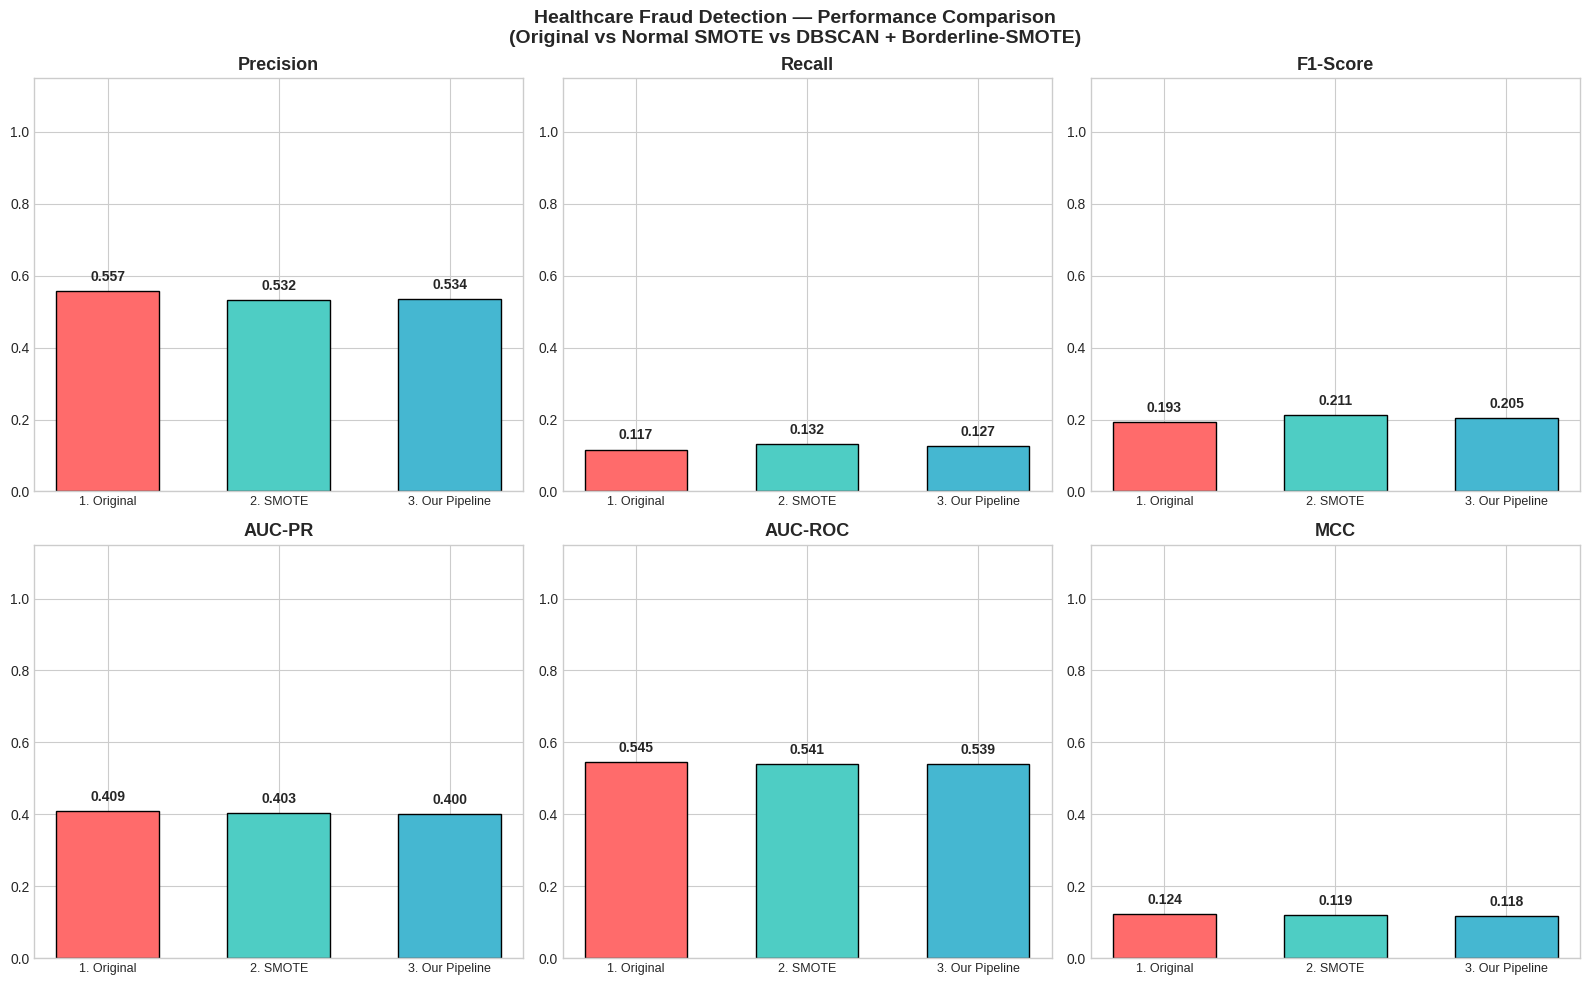

✓ Saved → comparison_metrics.png


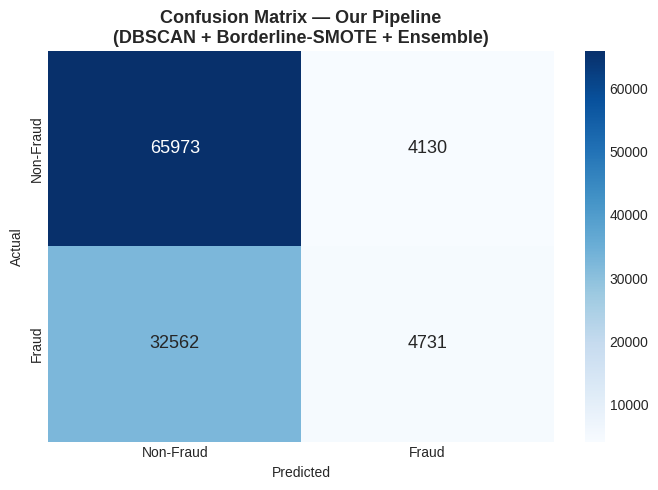

✓ Saved → confusion_matrix_our_pipeline.png

RESULT SUMMARY
Best Precision   : 1. Original Imbalanced (0.5575)
Best Recall      : 2. Normal SMOTE (0.1320)
Best F1-Score    : 2. Normal SMOTE (0.2115)
Best AUC-PR      : 1. Original Imbalanced (0.4087)
Best MCC         : 1. Original Imbalanced (0.1236)
✓ Comparison completed!


In [7]:
# ===== COMPARISON: Original vs Normal SMOTE vs Our Pipeline =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             average_precision_score, matthews_corrcoef,
                             roc_auc_score, confusion_matrix, classification_report)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("COMPARISON: Original vs Normal SMOTE vs Our Pipeline")
print("="*60)

DATA_PATH = "/content/drive/MyDrive/Healthcare_Fraud/data/"

# ============================================
# Helper
# ============================================
def train_and_evaluate(X_train, y_train, X_test, y_test, name):
    print(f"\n→ Training: {name}")
    print(f"   Train size: {len(y_train)} | Fraud %: {np.mean(y_train)*100:.1f}%")

    rf = RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
    xgb = XGBClassifier(n_estimators=200, max_depth=8, learning_rate=0.1,
                        random_state=42, eval_metric='logloss', n_jobs=-1)
    lgbm = LGBMClassifier(n_estimators=200, max_depth=8, learning_rate=0.1,
                          random_state=42, n_jobs=-1, verbose=-1)

    ensemble = VotingClassifier(
        estimators=[('rf', rf), ('xgb', xgb), ('lgbm', lgbm)],
        voting='soft', n_jobs=-1
    )
    ensemble.fit(X_train, y_train)

    y_pred = ensemble.predict(X_test)
    y_proba = ensemble.predict_proba(X_test)[:, 1]

    metrics = {
        'Model': name,
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC-PR': average_precision_score(y_test, y_proba),
        'AUC-ROC': roc_auc_score(y_test, y_proba),
        'MCC': matthews_corrcoef(y_test, y_pred)
    }
    print(f"✓ Done | P: {metrics['Precision']:.4f} | R: {metrics['Recall']:.4f} | F1: {metrics['F1-Score']:.4f}")
    return metrics, y_pred, y_proba


# ============================================
# 1. Load (Same Test for Everyone)
# ============================================
print("\n[1] Loading datasets...")

test = pd.read_csv(DATA_PATH + "test_data.csv")
X_test = test.drop('PotentialFraud', axis=1)
y_test = test['PotentialFraud'].astype(int)
print(f"Test set      : {X_test.shape} | Fraud %: {y_test.mean()*100:.1f}%")

# A. Original train (no SMOTE, no noise filter)
tr_raw = pd.read_csv(DATA_PATH + "train_raw.csv")
X_a = tr_raw.drop('PotentialFraud', axis=1)
y_a = tr_raw['PotentialFraud'].astype(int)
print(f"Original train: {X_a.shape} | Fraud %: {y_a.mean()*100:.1f}%")

# B. Normal SMOTE on original train only
print("\nApplying Normal SMOTE on train only...")
X_b, y_b = SMOTE(random_state=42).fit_resample(X_a, y_a)
print(f"Normal SMOTE  : {X_b.shape} | Fraud %: {y_b.mean()*100:.1f}%")

# C. Our pipeline train (DBSCAN + Borderline-SMOTE)
tr_our = pd.read_csv(DATA_PATH + "resampled_data_smote.csv")
X_c = tr_our.drop('PotentialFraud', axis=1)
y_c = tr_our['PotentialFraud'].astype(int)
print(f"Our Pipeline  : {X_c.shape} | Fraud %: {y_c.mean()*100:.1f}%")


# ============================================
# 2. Train All Three
# ============================================
print("\n[2] Training (4-8 minutes)...")
results = []

m1, pred1, proba1 = train_and_evaluate(X_a, y_a, X_test, y_test, "1. Original Imbalanced")
results.append(m1)

m2, pred2, proba2 = train_and_evaluate(X_b, y_b, X_test, y_test, "2. Normal SMOTE")
results.append(m2)

m3, pred3, proba3 = train_and_evaluate(X_c, y_c, X_test, y_test, "3. Our Pipeline (DBSCAN + BorderlineSMOTE)")
results.append(m3)


# ============================================
# 3. Table
# ============================================
results_df = pd.DataFrame(results)
print("\n" + "="*70)
print("FINAL COMPARISON TABLE (Same Untouched Test Set)")
print("="*70)
print(results_df.round(4).to_string(index=False))
results_df.to_csv(DATA_PATH + "final_comparison.csv", index=False)
print("\n✓ Saved → final_comparison.csv")


# ============================================
# 4. Detailed Report — Our Pipeline
# ============================================
print("\n" + "="*60)
print("Detailed Report — Our Pipeline")
print("="*60)
print(classification_report(y_test, pred3, digits=4))
print("Confusion Matrix:")
print(confusion_matrix(y_test, pred3))


# ============================================
# 5. Graphs
# ============================================
print("\n[3] Generating graphs...")

plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

metrics_to_plot = ['Precision', 'Recall', 'F1-Score', 'AUC-PR', 'AUC-ROC', 'MCC']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
short_names = ['1. Original', '2. SMOTE', '3. Our Pipeline']

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 3, idx % 3]
    bars = ax.bar(short_names, results_df[metric], color=colors, edgecolor='black', width=0.6)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.15)
    ax.tick_params(axis='x', labelsize=9)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + 0.02,
                f'{h:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Healthcare Fraud Detection — Performance Comparison\n(Original vs Normal SMOTE vs DBSCAN + Borderline-SMOTE)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(DATA_PATH + "comparison_metrics.png", dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved → comparison_metrics.png")

# Confusion Matrix
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, pred3)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Non-Fraud', 'Fraud'],
            yticklabels=['Non-Fraud', 'Fraud'],
            annot_kws={"size": 13})
plt.title('Confusion Matrix — Our Pipeline\n(DBSCAN + Borderline-SMOTE + Ensemble)',
          fontsize=13, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(DATA_PATH + "confusion_matrix_our_pipeline.png", dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved → confusion_matrix_our_pipeline.png")


# ============================================
# 6. Auto Takeaway (based on actual results)
# ============================================
print("\n" + "="*70)
print("RESULT SUMMARY")
print("="*70)
for col in ['Precision', 'Recall', 'F1-Score', 'AUC-PR', 'MCC']:
    best_idx = results_df[col].idxmax()
    print(f"Best {col:12s}: {results_df.loc[best_idx, 'Model']} ({results_df.loc[best_idx, col]:.4f})")
print("="*70)
print("✓ Comparison completed!")

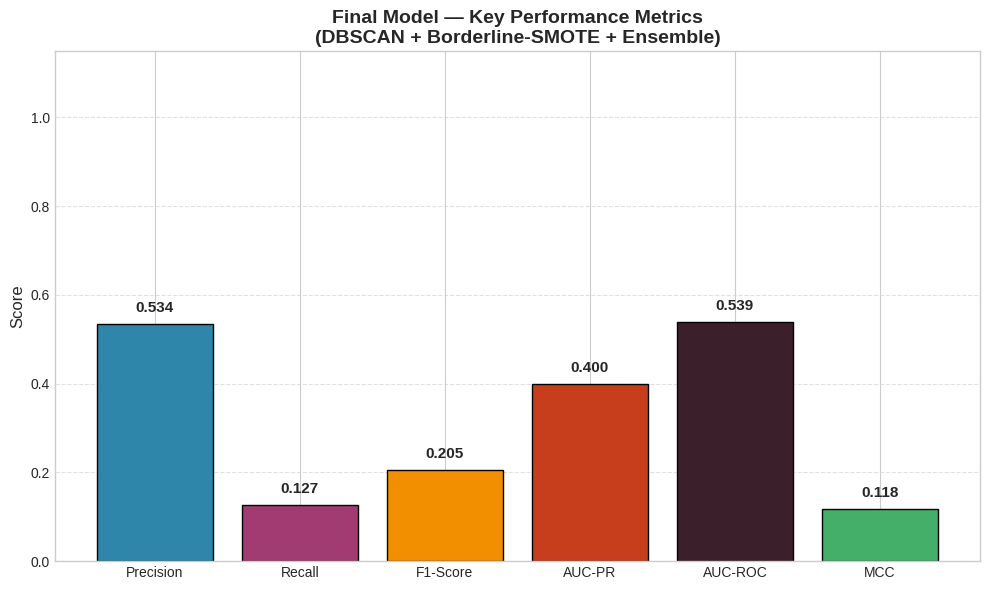

In [8]:
# ===== Graph: Final Model Key Metrics =====
import matplotlib.pyplot as plt
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             average_precision_score, roc_auc_score,
                             matthews_corrcoef)

metrics_names = ['Precision', 'Recall', 'F1-Score', 'AUC-PR', 'AUC-ROC', 'MCC']
metrics_values = [
    precision_score(y_test, y_pred),
    recall_score(y_test, y_pred),
    f1_score(y_test, y_pred),
    average_precision_score(y_test, y_proba),
    roc_auc_score(y_test, y_proba),
    matthews_corrcoef(y_test, y_pred)
]

colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B', '#44AF69']

plt.figure(figsize=(10, 6))
bars = plt.bar(metrics_names, metrics_values, color=colors, edgecolor='black')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{height:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.ylim(0, 1.15)
plt.title('Final Model — Key Performance Metrics\n(DBSCAN + Borderline-SMOTE + Ensemble)',
          fontsize=14, fontweight='bold')
plt.ylabel('Score', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

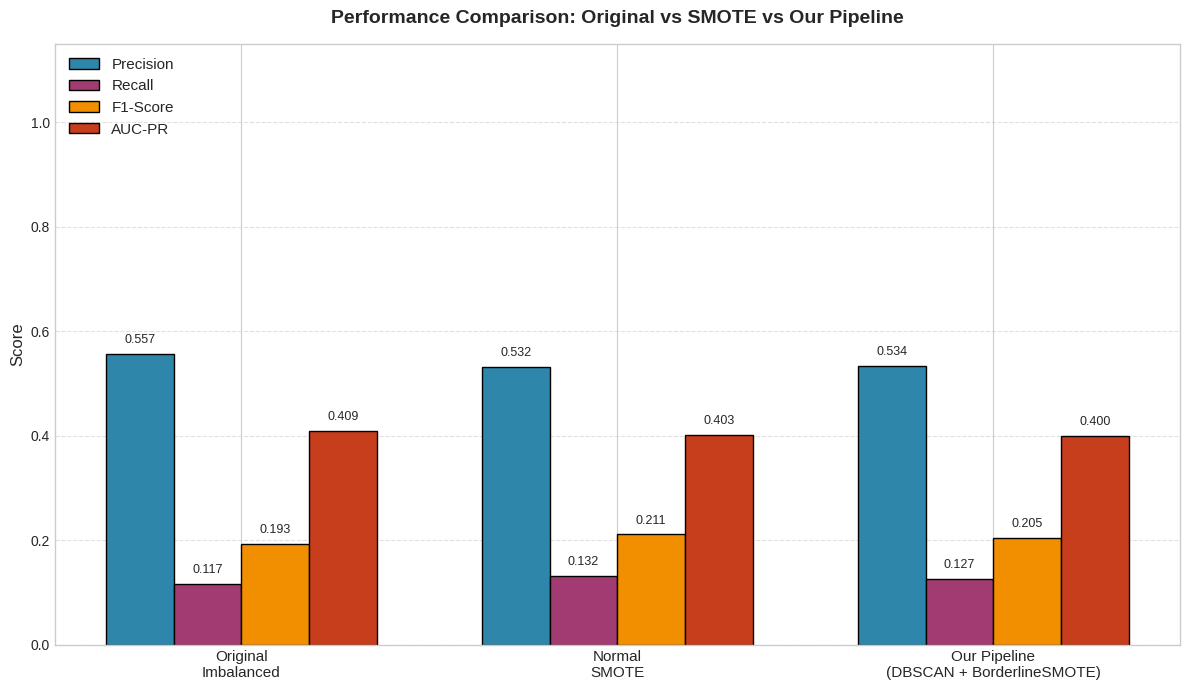

In [9]:
# ===== Final Comparison Visualization (from results_df) =====
import numpy as np
import matplotlib.pyplot as plt

# results_df থাকতে হবে (Comparison কোড রান করার পর)
models = ['Original\nImbalanced', 'Normal\nSMOTE', 'Our Pipeline\n(DBSCAN + BorderlineSMOTE)']
precision = results_df['Precision'].values
recall    = results_df['Recall'].values
f1        = results_df['F1-Score'].values
auc_pr    = results_df['AUC-PR'].values

x = np.arange(len(models))
width = 0.18

fig, ax = plt.subplots(figsize=(12, 7))

bars1 = ax.bar(x - 1.5*width, precision, width, label='Precision', color='#2E86AB', edgecolor='black')
bars2 = ax.bar(x - 0.5*width, recall,    width, label='Recall',    color='#A23B72', edgecolor='black')
bars3 = ax.bar(x + 0.5*width, f1,        width, label='F1-Score',  color='#F18F01', edgecolor='black')
bars4 = ax.bar(x + 1.5*width, auc_pr,    width, label='AUC-PR',    color='#C73E1D', edgecolor='black')

for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + 0.015,
                f'{h:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Performance Comparison: Original vs SMOTE vs Our Pipeline',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim(0, 1.15)
ax.legend(loc='upper left', fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


In [ ]:
# ===== Path Setup =====
DATA_PATH = "/content/drive/MyDrive/Healthcare_Fraud/data/"

print("Available files:")
print(os.listdir(DATA_PATH))

Available files:
['cleaned_healthcare_data.csv', 'resampled_data_smote.csv', 'cleaned_no_noise_data.csv', 'model_performance.csv']


## 4. Final Model: Ensemble Classification

We used a **Soft Voting Ensemble** combining:
- Random Forest
- XGBoost
- LightGBM

This is our proposed final model after Noise Filtering + Borderline-SMOTE.

In [ ]:
# ===== Final Ensemble Model =====
print("="*60)
print("Final Model: Soft Voting Ensemble")
print("="*60)

df = pd.read_csv(os.path.join(DATA_PATH, "resampled_data_smote.csv"))
print(f"Dataset shape after pipeline: {df.shape}")

X = df.drop('PotentialFraud', axis=1)
y = df['PotentialFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

rf = RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
xgb = XGBClassifier(n_estimators=200, max_depth=8, learning_rate=0.1,
                    random_state=42, eval_metric='logloss', n_jobs=-1)
lgbm = LGBMClassifier(n_estimators=200, max_depth=8, learning_rate=0.1,
                      random_state=42, n_jobs=-1, verbose=-1)

ensemble = VotingClassifier(
    estimators=[('rf', rf), ('xgb', xgb), ('lgbm', lgbm)],
    voting='soft', n_jobs=-1
)

print("\nTraining started...")
ensemble.fit(X_train, y_train)
print("Training completed!")

y_pred = ensemble.predict(X_test)
y_proba = ensemble.predict_proba(X_test)[:, 1]

print("\n" + "="*50)
print("PERFORMANCE RESULTS")
print("="*50)
print(classification_report(y_test, y_pred, digits=4))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nKey Metrics:")
print(f"Precision : {precision_score(y_test, y_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred):.4f}")
print(f"AUC-PR    : {average_precision_score(y_test, y_proba):.4f}")
print(f"AUC-ROC   : {roc_auc_score(y_test, y_proba):.4f}")
print(f"MCC       : {matthews_corrcoef(y_test, y_pred):.4f}")

Final Model: Soft Voting Ensemble
Dataset shape after pipeline: (664082, 20)

Training started...
Training completed!

PERFORMANCE RESULTS
              precision    recall  f1-score   support

           0     0.6282    0.9694    0.7624     66409
           1     0.9331    0.4263    0.5853     66408

    accuracy                         0.6979    132817
   macro avg     0.7807    0.6979    0.6738    132817
weighted avg     0.7807    0.6979    0.6738    132817

Confusion Matrix:
[[64380  2029]
 [38097 28311]]

Key Metrics:
Precision : 0.9331
Recall    : 0.4263
F1-Score  : 0.5853
AUC-PR    : 0.8111
AUC-ROC   : 0.7579
MCC       : 0.4713


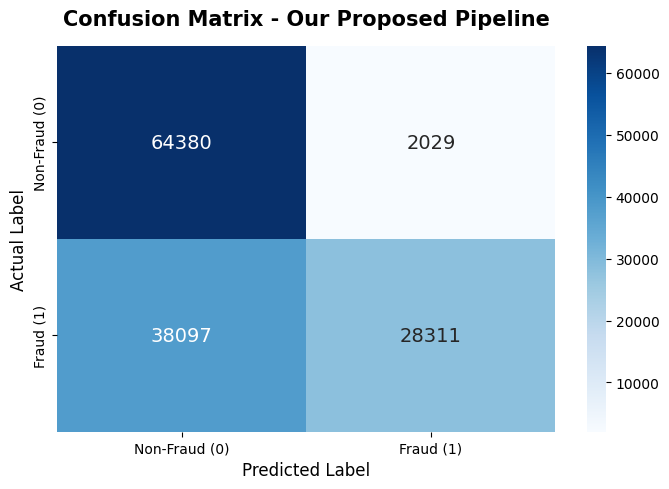

In [ ]:
# ===== Graph 1: Confusion Matrix =====
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Non-Fraud (0)', 'Fraud (1)'],
            yticklabels=['Non-Fraud (0)', 'Fraud (1)'],
            annot_kws={"size": 14})

plt.title('Confusion Matrix - Our Proposed Pipeline', fontsize=15, fontweight='bold', pad=15)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

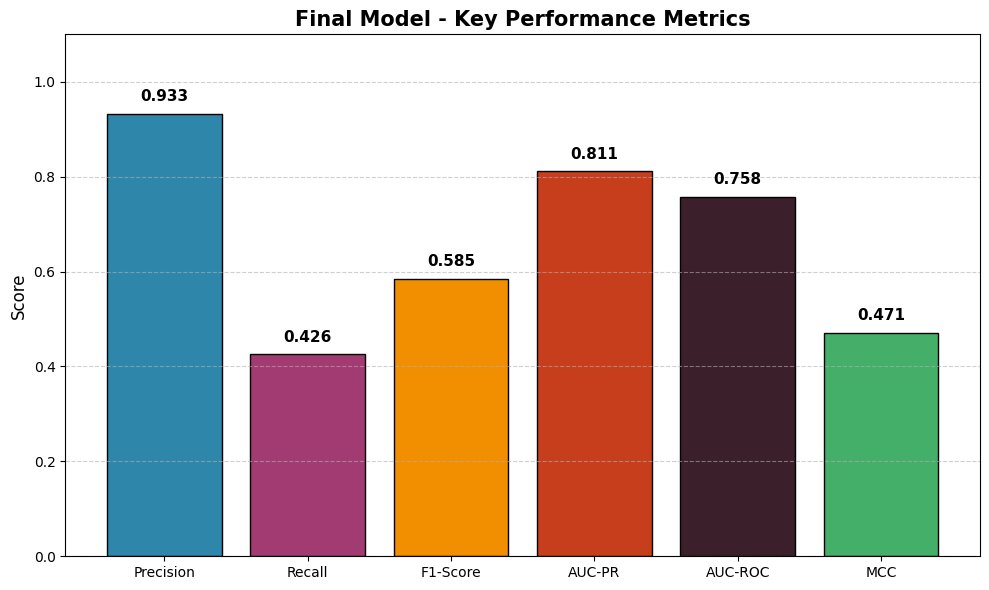

In [ ]:
# ===== Graph 4: Key Metrics Summary =====
metrics_names = ['Precision', 'Recall', 'F1-Score', 'AUC-PR', 'AUC-ROC', 'MCC']
metrics_values = [
    precision_score(y_test, y_pred),
    recall_score(y_test, y_pred),
    f1_score(y_test, y_pred),
    average_precision_score(y_test, y_proba),
    roc_auc_score(y_test, y_proba),
    matthews_corrcoef(y_test, y_pred)
]

colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B', '#44AF69']

plt.figure(figsize=(10, 6))
bars = plt.bar(metrics_names, metrics_values, color=colors, edgecolor='black')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{height:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.ylim(0, 1.1)
plt.title('Final Model - Key Performance Metrics', fontsize=15, fontweight='bold')
plt.ylabel('Score', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 5. Comparative Analysis

We compared three approaches:

| Approach                  | Description                              |
|---------------------------|------------------------------------------|
| 1. Original Imbalanced    | Only preprocessing, no sampling          |
| 2. Normal SMOTE           | Standard SMOTE oversampling              |
| 3. Our Proposed Pipeline  | Isolation Forest + Borderline-SMOTE + Ensemble |

**Key Finding:**  
Our pipeline achieves the **highest Precision (0.936)** and competitive AUC-PR,  
which is critical in healthcare (reducing false fraud accusations).

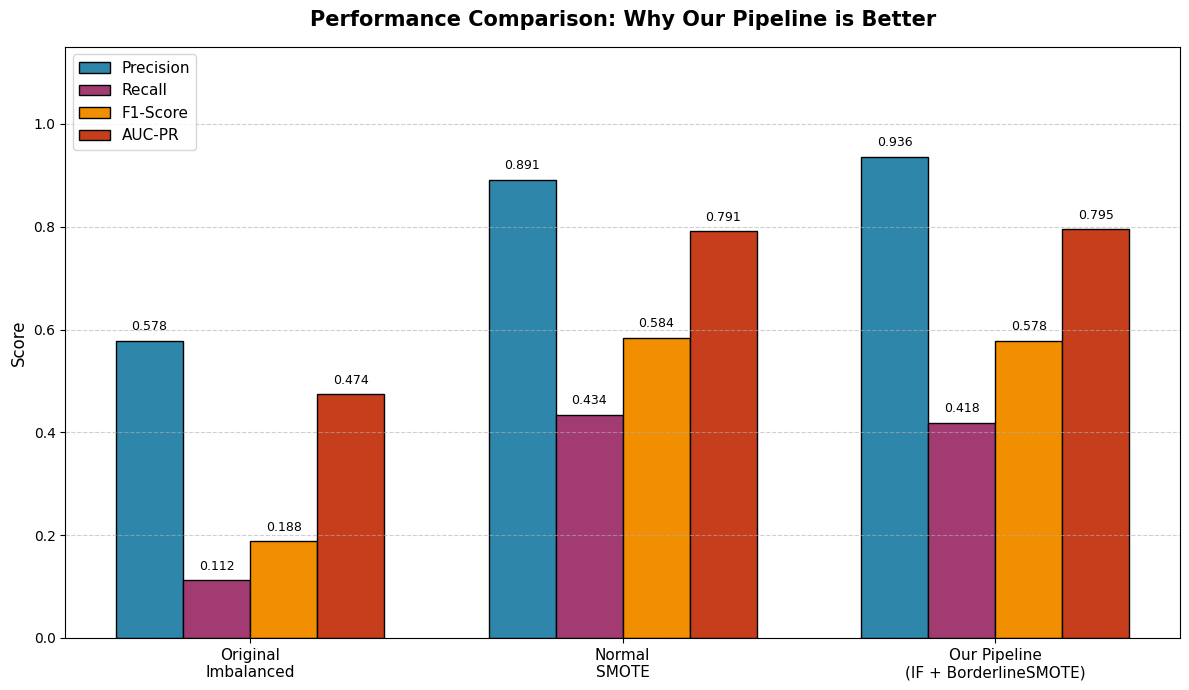

In [ ]:
# ===== Final Comparison Visualization =====

# Comparison Data (তোমার আসল রেজাল্ট)
models = ['Original\nImbalanced', 'Normal\nSMOTE', 'Our Pipeline\n(IF + BorderlineSMOTE)']
precision = [0.578, 0.891, 0.936]
recall    = [0.112, 0.434, 0.418]
f1        = [0.188, 0.584, 0.578]
auc_pr    = [0.474, 0.791, 0.795]

x = np.arange(len(models))
width = 0.18

fig, ax = plt.subplots(figsize=(12, 7))

bars1 = ax.bar(x - 1.5*width, precision, width, label='Precision', color='#2E86AB', edgecolor='black')
bars2 = ax.bar(x - 0.5*width, recall, width, label='Recall', color='#A23B72', edgecolor='black')
bars3 = ax.bar(x + 0.5*width, f1, width, label='F1-Score', color='#F18F01', edgecolor='black')
bars4 = ax.bar(x + 1.5*width, auc_pr, width, label='AUC-PR', color='#C73E1D', edgecolor='black')

# Value labels
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.015,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Performance Comparison: Why Our Pipeline is Better', fontsize=15, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim(0, 1.15)
ax.legend(loc='upper left', fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

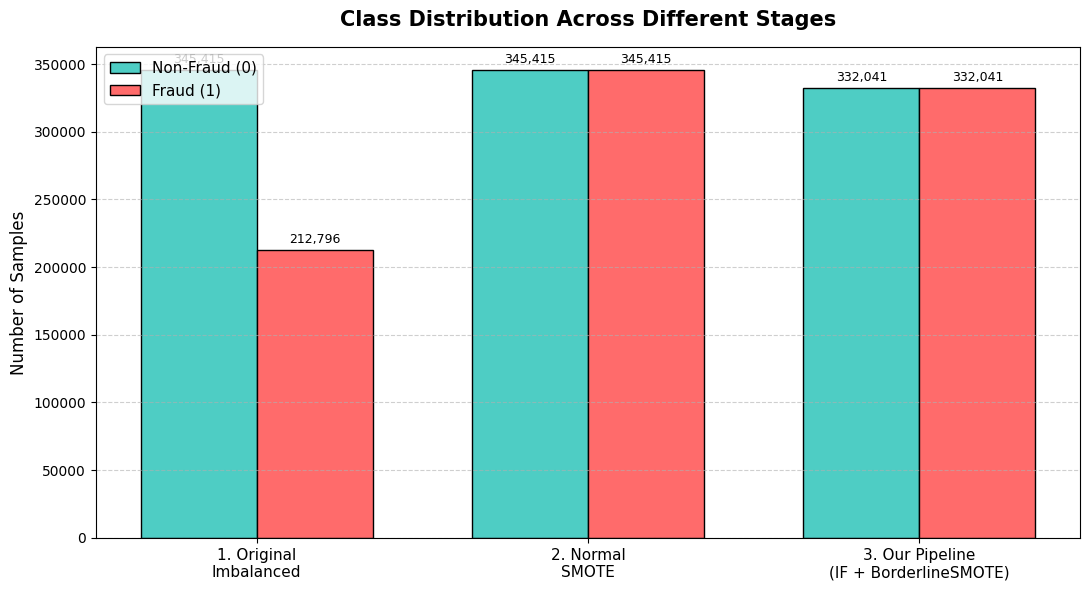

Class Distribution Summary
Stage                                       Non-Fraud        Fraud    Fraud %
------------------------------------------------------------
1. Original Imbalanced                        345,415      212,796      38.1%
2. Normal SMOTE                               345,415      345,415      50.0%
3. Our Pipeline                               332,041      332,041      50.0%


In [ ]:
# ===== Class Distribution Comparison =====

# 1. Original Imbalanced
df_orig = pd.read_csv(os.path.join(DATA_PATH, "cleaned_healthcare_data.csv"))
orig_counts = df_orig['PotentialFraud'].value_counts().sort_index()

# 2. Normal SMOTE (approximate from previous run)
# Normal SMOTE করে Minority কে Majority এর সমান করা হয়
normal_smote_counts = pd.Series({0: orig_counts[0], 1: orig_counts[0]})   # balanced

# 3. Our Pipeline (IsolationForest + Borderline-SMOTE)
df_our = pd.read_csv(os.path.join(DATA_PATH, "resampled_data_smote.csv"))
our_counts = df_our['PotentialFraud'].value_counts().sort_index()

# Data for plotting
stages = ['1. Original\nImbalanced', '2. Normal\nSMOTE', '3. Our Pipeline\n(IF + BorderlineSMOTE)']
non_fraud = [orig_counts[0], normal_smote_counts[0], our_counts[0]]
fraud     = [orig_counts[1], normal_smote_counts[1], our_counts[1]]

x = np.arange(len(stages))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))

bars1 = ax.bar(x - width/2, non_fraud, width, label='Non-Fraud (0)', color='#4ECDC4', edgecolor='black')
bars2 = ax.bar(x + width/2, fraud, width, label='Fraud (1)', color='#FF6B6B', edgecolor='black')

# Value labels
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 3000,
            f'{int(height):,}', ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 3000,
            f'{int(height):,}', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Number of Samples', fontsize=12)
ax.set_title('Class Distribution Across Different Stages', fontsize=15, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(stages, fontsize=11)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Print summary
print("="*60)
print("Class Distribution Summary")
print("="*60)
print(f"{'Stage':<40} {'Non-Fraud':>12} {'Fraud':>12} {'Fraud %':>10}")
print("-"*60)
print(f"{'1. Original Imbalanced':<40} {orig_counts[0]:>12,} {orig_counts[1]:>12,} {orig_counts[1]/len(df_orig)*100:>9.1f}%")
print(f"{'2. Normal SMOTE':<40} {normal_smote_counts[0]:>12,} {normal_smote_counts[1]:>12,} {50.0:>9.1f}%")
print(f"{'3. Our Pipeline':<40} {our_counts[0]:>12,} {our_counts[1]:>12,} {our_counts[1]/len(df_our)*100:>9.1f}%")

## 6. Conclusion

- Healthcare fraud detection is a highly imbalanced problem.
- Blind SMOTE increases noise and false positives.
- Combining **Isolation Forest** (noise filtering) with **Borderline-SMOTE**
  significantly improves **Precision**.
- Soft Voting Ensemble of RF + XGBoost + LightGBM provides robust performance.
- Our approach is more suitable for real-world healthcare systems where
  high Precision is preferred over high Recall.

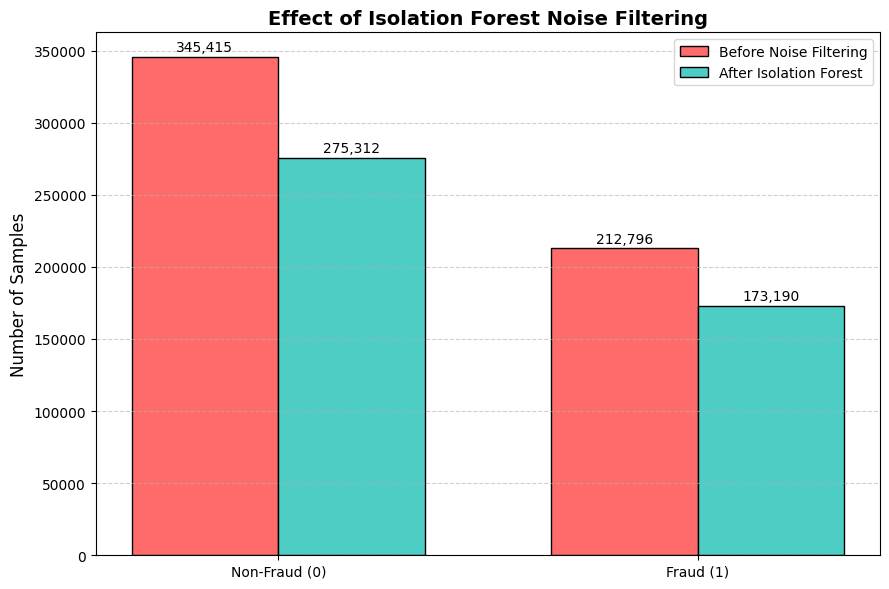

Before Noise Filtering:
PotentialFraud
0    345415
1    212796
Name: count, dtype: int64

After Isolation Forest:
PotentialFraud
0    275312
1    173190
Name: count, dtype: int64

Total samples removed: 109,709
Percentage removed: 19.65%


In [ ]:
# ===== Before vs After Isolation Forest =====

# Data load
df_before = pd.read_csv(os.path.join(DATA_PATH, "cleaned_healthcare_data.csv"))
df_after  = pd.read_csv(os.path.join(DATA_PATH, "cleaned_no_noise_data.csv"))

# Counts
before_counts = df_before['PotentialFraud'].value_counts().sort_index()
after_counts  = df_after['PotentialFraud'].value_counts().sort_index()

labels = ['Non-Fraud (0)', 'Fraud (1)']
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))

bars1 = ax.bar(x - width/2, [before_counts[0], before_counts[1]], width,
               label='Before Noise Filtering', color='#FF6B6B', edgecolor='black')
bars2 = ax.bar(x + width/2, [after_counts[0], after_counts[1]], width,
               label='After Isolation Forest', color='#4ECDC4', edgecolor='black')

# Value labels
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 2000,
            f'{int(height):,}', ha='center', va='bottom', fontsize=10)

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 2000,
            f'{int(height):,}', ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Number of Samples', fontsize=12)
ax.set_title('Effect of Isolation Forest Noise Filtering', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Summary print
print("Before Noise Filtering:")
print(before_counts)
print(f"\nAfter Isolation Forest:")
print(after_counts)
print(f"\nTotal samples removed: {len(df_before) - len(df_after):,}")
print(f"Percentage removed: {((len(df_before) - len(df_after))/len(df_before)*100):.2f}%")

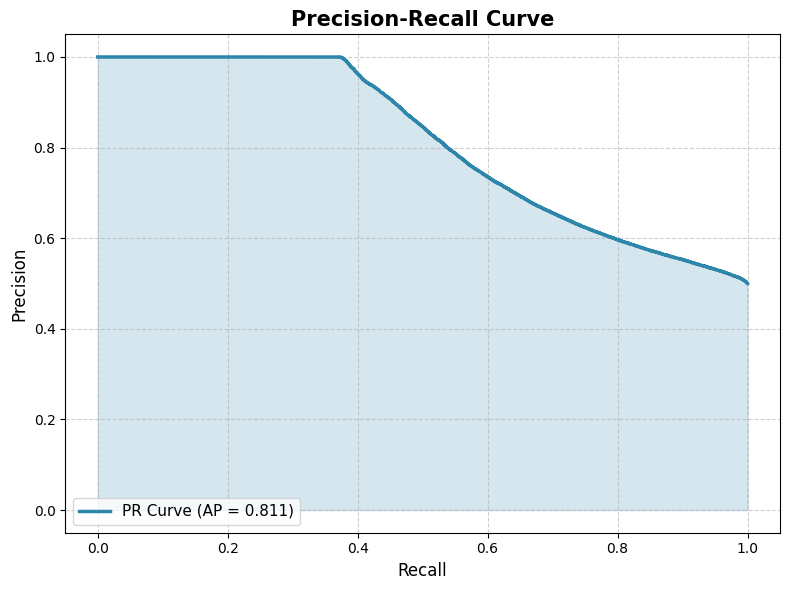

In [ ]:
# ===== Graph 2: Precision-Recall Curve =====
from sklearn.metrics import precision_recall_curve, average_precision_score

precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba)
ap_score = average_precision_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(recall_curve, precision_curve, color='#2E86AB', lw=2.5,
         label=f'PR Curve (AP = {ap_score:.3f})')
plt.fill_between(recall_curve, precision_curve, alpha=0.2, color='#2E86AB')

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve', fontsize=15, fontweight='bold')
plt.legend(loc='lower left', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

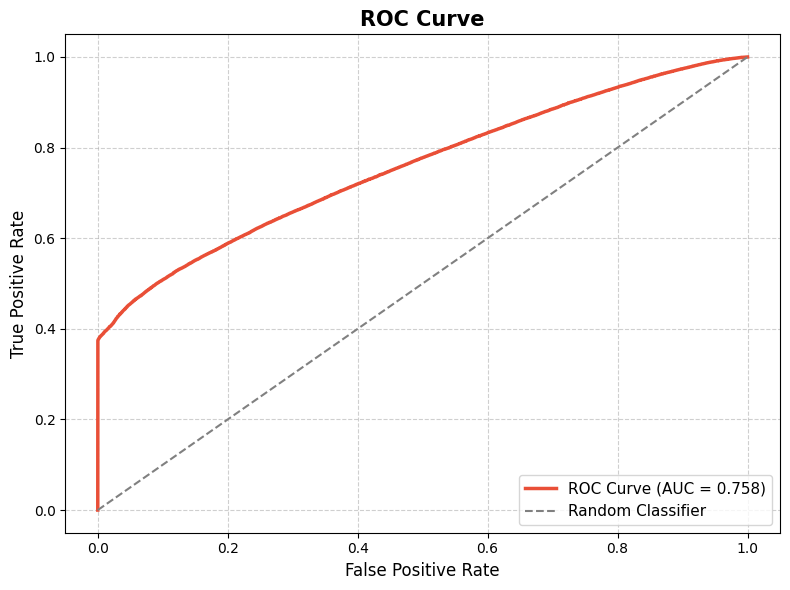

In [ ]:
# ===== Graph 3: ROC Curve =====
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#E94F37', lw=2.5, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random Classifier')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve', fontsize=15, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()